# ccp-esg-stress-testing

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

--- Fetching Data from 2018-01-01 to 2024-01-01 ---


C:\Users\Yahya\AppData\Local\Temp\ipykernel_13012\3079854932.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_data.rename(columns={'^GSPC': 'SP500', '^VIX': 'VIX', '^TNX': 'US10Y'}, inplace=True)



[SUCCESS] Data saved to: c:\Users\Yahya\Desktop\My folder\WQU\10. Capstone\Thesis Work\Risk Management & Sustainability (ESG)\Quantifying Systemic Risk in Central Clearing Counterparties (CCPs)\data\raw\market_data_raw.csv
Shape: (1509, 12)


<Figure size 1400x700 with 0 Axes>

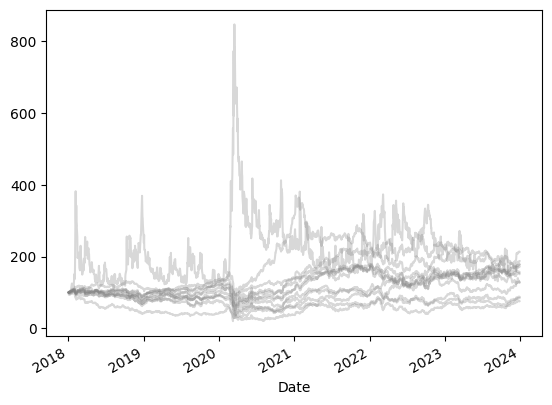

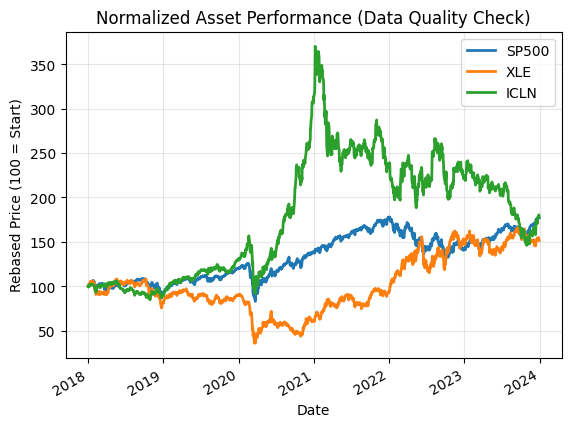

Ticker            BAC       BCS          C         DB          GS      ICLN  \
Date                                                                          
2018-01-02  24.776775  8.380320  56.874508  16.866777  214.265945  8.423617   
2018-01-03  24.693907  8.349930  57.050423  16.718441  212.271423  8.405806   
2018-01-04  25.017086  8.395514  57.754089  17.250713  215.238098  8.343476   
2018-01-05  25.133097  8.182780  57.677616  16.186172  214.140244  8.370191   
2018-01-08  24.959080  8.235965  57.004539  15.968031  211.031082  8.494851   

Ticker            JPM         MS        XLE        SP500  US10Y   VIX  
Date                                                                   
2018-01-02  86.340897  41.064857  25.915483  2695.810059  2.465  9.77  
2018-01-03  86.428894  41.175026  26.303600  2713.060059  2.447  9.15  
2018-01-04  87.667007  41.804485  26.462379  2723.989990  2.453  9.22  
2018-01-05  87.104233  41.788754  26.451792  2743.149902  2.476  9.22  
2018-01-08  87

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
import seaborn as sns

# 1. Define Constants
START_DATE = "2018-01-01"
END_DATE = "2024-01-01"

# Define Tickers
CM_TICKERS = ['JPM', 'GS', 'MS', 'BAC', 'C', 'DB', 'BCS'] 
MACRO_TICKERS = ['^GSPC', '^VIX', '^TNX'] 
ESG_TICKERS = ['XLE', 'ICLN'] 

ALL_TICKERS = CM_TICKERS + MACRO_TICKERS + ESG_TICKERS

def fetch_and_save_data():
    print(f"--- Fetching Data from {START_DATE} to {END_DATE} ---")
    
    # auto_adjust=False ensures 'Adj Close' is returned. 
    # We also turn off progress bar to keep output clean.
    download_data = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
    
    # Robust Column Extraction
    # Check if 'Adj Close' exists, otherwise use 'Close'
    if 'Adj Close' in download_data.columns.levels[0]:
        raw_data = download_data['Adj Close']
    elif 'Close' in download_data.columns.levels[0]:
        print("[NOTE] 'Adj Close' not found. Using 'Close' (likely already adjusted).")
        raw_data = download_data['Close']
    else:
        # Fallback for flat dataframe (rare, but possible if single ticker or different version)
        if 'Adj Close' in download_data.columns:
            raw_data = download_data['Adj Close']
        elif 'Close' in download_data.columns:
            raw_data = download_data['Close']
        else:
            raise KeyError(f"Could not find Price columns. Available: {download_data.columns}")

    # Check for missing values
    if raw_data.isnull().sum().sum() > 0:
        print("\n[WARNING] Missing values detected. Filling with forward fill method...")
        raw_data = raw_data.fillna(method='ffill').dropna()
    
    # Rename columns for clarity
    raw_data.rename(columns={'^GSPC': 'SP500', '^VIX': 'VIX', '^TNX': 'US10Y'}, inplace=True)
    
    base_path = os.getcwd()
    
    if "notebooks" in base_path:
        
        root_path = os.path.abspath(os.path.join(base_path, "..", ".."))
    else:
        root_path = base_path
        
    output_path = os.path.join(root_path, "data", "raw", "market_data_raw.csv")
    
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    raw_data.to_csv(output_path)
    print(f"\n[SUCCESS] Data saved to: {output_path}")
    print(f"Shape: {raw_data.shape}")
    
    return raw_data

# Execute
try:
    df = fetch_and_save_data()

    # Quick Visualization Check
    plt.figure(figsize=(14, 7))
    # Normalize to start at 100 for comparison
    (df / df.iloc[0] * 100).plot(legend=False, alpha=0.3, color='gray')
    
    # Plot specific lines if they exist in columns
    targets = ['SP500', 'XLE', 'ICLN']
    valid_targets = [t for t in targets if t in df.columns]
    
    if valid_targets:
        (df[valid_targets] / df[valid_targets].iloc[0] * 100).plot(linewidth=2)
        plt.legend(valid_targets)
        
    plt.title("Normalized Asset Performance (Data Quality Check)")
    plt.ylabel("Rebased Price (100 = Start)")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Display first few rows
    print(df.head())

except Exception as e:
    print(f"An error occurred: {e}")